In [4]:
import pandas as pd
from pathlib import Path

# Load raw dataset (contains the smiles column)
raw_data = pd.read_parquet('../data/raw/QM_137k.parquet')
print("Raw dataset shape:", raw_data.shape)
display(raw_data.head())


Raw dataset shape: (136219, 5)


,smiles,hirshfeld_charges,hirshfeld_fukui_elec,hirshfeld_fukui_neu,CDD
0,CNC(=S)N/N=C/c1c(O)ccc2ccccc12,[-0.026644 -0.075508 0.096217 -0.287798 -0.02...,[0.010333 0.015418 0.022324 0.111353 0.01318 ...,[0.011959 0.021591 0.017375 0.232471 0.050276 ...,"[-0.07558000000000001, -0.18802500000000003, 0..."
1,O=C(NCCn1cccc1)c1cccc2ccccc12,[-0.292411 0.170263 -0.085754 0.002736 0.01...,[ 0.04781 0.029278 0.02064 0.00908 0.00...,[0.026718 0.004006 0.010781 0.008124 0.007945 ...,"[-0.6593499999999999, 0.30724199999999996, -0...."
2,C=C(C)[C@H]1C[C@@H]2OO[C@H]1C=C2C,[-0.101749 0.012339 -0.07947 -0.020027 -0.05...,[0.082324 0.05751 0.020546 0.011972 0.01684 ...,[0.065786 0.029895 0.018721 0.020284 0.022533 ...,"[-0.35160800000000003, -0.062727, -0.198206999..."
3,OCCCc1cc[nH]n1,[-0.268379 0.027614 -0.050745 -0.045047 0.03...,[0.025129 0.01567 0.021808 0.028649 0.085482 ...,[0.210686 0.044551 0.042072 0.021857 0.059646 ...,"[-0.772573, -0.004993000000000011, -0.16537000..."
4,CC(=N)NCc1cccc(CNCc2ccncc2)c1,[-8.31620e-02 1.14954e-01 -2.74544e-01 -1.003...,[0.005584 0.007569 0.010781 0.00532 0.010963 ...,[0.011283 0.029042 0.090907 0.087975 0.015502 ...,"[-0.183191, 0.193297, -0.650776, -0.294033, -0..."


In [6]:

# Load processed dataset (Molecule is the index from raw_data)
proc_data = pd.read_csv('../data/processed/qm_calc_data.csv')
display("Processed dataset shape:", proc_data.shape)
display(proc_data.head())

'Processed dataset shape:'

(920, 7)

,Molecule,Conformation,hirshfeld_charges,hirshfeld_fukui_elec,hirshfeld_fukui_neu,CDD,Log_CDD
0,11912,2,"[-0.8328368871, 0.5788824669, -0.8364176159, -...","[-0.7904237058, 0.5775246483, -0.8350919605, -...","[-0.7541737204, 0.5672330754, -0.8225331821, -...","[-0.12107634800000011, 0.013007210099999944, -...","[-0.9169406870495196, -1.8858158447225923, -1...."
1,11912,3,"[-0.8292215009, 0.5679183521, -0.83810306, -0....","[-0.7896504539, 0.5779680971, -0.8343226009, -...","[-0.7427028135, 0.5668231064, -0.82014178, -0....","[-0.12608973440000004, -0.00895449930000003, -...","[-0.8993202700876205, -2.047958693156822, -1.6..."
2,12149,0,"[-0.5921010727, -0.2125531186, -0.5928916186, ...","[-0.5922353134, -0.2149126776, -0.5940200654, ...","[-0.5967331196, -0.2153853267, -0.595513798, -...","[0.004766287599999974, 0.0051917670999999666, ...","[-2.3218197556688422, -2.284684797997657, -2.4..."
3,12149,1,"[-0.6073014295, -0.2139855303, -0.5909325852, ...","[-0.6036356112, -0.2159291861, -0.5926209025, ...","[-0.6090814427, -0.2091436768, -0.5985050578, ...","[-0.0018858051000000264, -0.002898197699999993...","[-2.7245031940845785, -2.537871992539606, -2.0..."
4,12149,2,"[-0.5991128342, -0.2259256802, -0.6151157903, ...","[-0.5999157229, -0.212508695, -0.5932151976, -...","[-0.6040844303, -0.2049871707, -0.5989736966, ...","[0.005774484799999868, -0.03435549470000002, -...","[-2.238486757496124, -1.4640037934792547, -1.4..."


In [8]:
desc_data = pd.read_parquet('../data/137k_descriptors.parquet')
display("Descriptors dataset shape:", desc_data.shape)
display(desc_data.head())

'Descriptors dataset shape:'

(133632, 23)

,smiles,mw,fsp3,n_lipinski_hba,n_lipinski_hbd,n_rings,n_hetero_atoms,n_heavy_atoms,n_rotatable_bonds,n_radical_electrons,...,sas,n_aliphatic_carbocycles,n_aliphatic_heterocyles,n_aliphatic_rings,n_aromatic_carbocycles,n_aromatic_heterocyles,n_aromatic_rings,n_saturated_carbocycles,n_saturated_heterocyles,n_saturated_rings
0,CNC(=S)N/N=C/c1c(O)ccc2ccccc12,259.077933,0.076923,4,3,2,5,18,2,0,...,2.283918,0,0,0,2,0,2,0,0,0
1,O=C(NCCn1cccc1)c1cccc2ccccc12,264.126263,0.117647,3,1,3,3,20,4,0,...,1.931177,0,0,0,2,1,3,0,0,0
2,C=C(C)[C@H]1C[C@@H]2OO[C@H]1C=C2C,166.099380,0.600000,2,0,3,2,12,1,0,...,5.470026,1,2,3,0,0,0,0,1,1
3,OCCCc1cc[nH]n1,126.079313,0.500000,3,2,1,3,9,3,0,...,3.277522,0,0,0,0,1,1,0,0,0
4,CC(=N)NCc1cccc(CNCc2ccncc2)c1,268.168797,0.250000,4,3,2,4,20,6,0,...,2.258991,0,0,0,1,1,2,0,0,0


In [14]:
raw_reset = raw_data.reset_index(drop=False)
proc_data['smiles'] = proc_data['Molecule'].map(raw_reset.set_index('index')['smiles'])
proc_merge = pd.merge(proc_data, desc_data, on='smiles', how='left')



In [9]:

raw_merged = pd.merge(raw_data, desc_data, on='smiles', how='left')
display("Merged raw dataset shape:", raw_merged.shape)
display(raw_merged.head())

'Merged raw dataset shape:'

(136219, 27)

,smiles,hirshfeld_charges,hirshfeld_fukui_elec,hirshfeld_fukui_neu,CDD,mw,fsp3,n_lipinski_hba,n_lipinski_hbd,n_rings,...,sas,n_aliphatic_carbocycles,n_aliphatic_heterocyles,n_aliphatic_rings,n_aromatic_carbocycles,n_aromatic_heterocyles,n_aromatic_rings,n_saturated_carbocycles,n_saturated_heterocyles,n_saturated_rings
0,CNC(=S)N/N=C/c1c(O)ccc2ccccc12,[-0.026644 -0.075508 0.096217 -0.287798 -0.02...,[0.010333 0.015418 0.022324 0.111353 0.01318 ...,[0.011959 0.021591 0.017375 0.232471 0.050276 ...,"[-0.07558000000000001, -0.18802500000000003, 0...",259.077933,0.076923,4,3,2,...,2.283918,0,0,0,2,0,2,0,0,0
1,O=C(NCCn1cccc1)c1cccc2ccccc12,[-0.292411 0.170263 -0.085754 0.002736 0.01...,[ 0.04781 0.029278 0.02064 0.00908 0.00...,[0.026718 0.004006 0.010781 0.008124 0.007945 ...,"[-0.6593499999999999, 0.30724199999999996, -0....",264.126263,0.117647,3,1,3,...,1.931177,0,0,0,2,1,3,0,0,0
2,C=C(C)[C@H]1C[C@@H]2OO[C@H]1C=C2C,[-0.101749 0.012339 -0.07947 -0.020027 -0.05...,[0.082324 0.05751 0.020546 0.011972 0.01684 ...,[0.065786 0.029895 0.018721 0.020284 0.022533 ...,"[-0.35160800000000003, -0.062727, -0.198206999...",166.099380,0.600000,2,0,3,...,5.470026,1,2,3,0,0,0,0,1,1
3,OCCCc1cc[nH]n1,[-0.268379 0.027614 -0.050745 -0.045047 0.03...,[0.025129 0.01567 0.021808 0.028649 0.085482 ...,[0.210686 0.044551 0.042072 0.021857 0.059646 ...,"[-0.772573, -0.004993000000000011, -0.16537000...",126.079313,0.500000,3,2,1,...,3.277522,0,0,0,0,1,1,0,0,0
4,CC(=N)NCc1cccc(CNCc2ccncc2)c1,[-8.31620e-02 1.14954e-01 -2.74544e-01 -1.003...,[0.005584 0.007569 0.010781 0.00532 0.010963 ...,[0.011283 0.029042 0.090907 0.087975 0.015502 ...,"[-0.183191, 0.193297, -0.650776, -0.294033, -0...",268.168797,0.250000,4,3,2,...,2.258991,0,0,0,1,1,2,0,0,0


In [11]:

raw_data_reset = raw_data.reset_index(drop=False) 

proc_data['smiles'] = proc_data['Molecule'].map(raw_data_reset.set_index('index')['smiles'])

proc_merged = pd.merge(proc_data, desc_data, on='smiles', how='left')
display("Merged processed dataset shape:", proc_merged.shape)
display(proc_merged.head())


'Merged processed dataset shape:'

(920, 30)

,Molecule,Conformation,hirshfeld_charges,hirshfeld_fukui_elec,hirshfeld_fukui_neu,CDD,Log_CDD,smiles,mw,fsp3,...,sas,n_aliphatic_carbocycles,n_aliphatic_heterocyles,n_aliphatic_rings,n_aromatic_carbocycles,n_aromatic_heterocyles,n_aromatic_rings,n_saturated_carbocycles,n_saturated_heterocyles,n_saturated_rings
0,11912,2,"[-0.8328368871, 0.5788824669, -0.8364176159, -...","[-0.7904237058, 0.5775246483, -0.8350919605, -...","[-0.7541737204, 0.5672330754, -0.8225331821, -...","[-0.12107634800000011, 0.013007210099999944, -...","[-0.9169406870495196, -1.8858158447225923, -1....",N=C(N)NCCN1CCCCCCC1,198.184447,0.900,...,1.998004,0,1,1,0,0,0,0,1,1
1,11912,3,"[-0.8292215009, 0.5679183521, -0.83810306, -0....","[-0.7896504539, 0.5779680971, -0.8343226009, -...","[-0.7427028135, 0.5668231064, -0.82014178, -0....","[-0.12608973440000004, -0.00895449930000003, -...","[-0.8993202700876205, -2.047958693156822, -1.6...",N=C(N)NCCN1CCCCCCC1,198.184447,0.900,...,1.998004,0,1,1,0,0,0,0,1,1
2,12149,0,"[-0.5921010727, -0.2125531186, -0.5928916186, ...","[-0.5922353134, -0.2149126776, -0.5940200654, ...","[-0.5967331196, -0.2153853267, -0.595513798, -...","[0.004766287599999974, 0.0051917670999999666, ...","[-2.3218197556688422, -2.284684797997657, -2.4...",CC(C)C[C@H](CN)CC(=O)O,159.125929,0.875,...,2.672158,0,0,0,0,0,0,0,0,0
3,12149,1,"[-0.6073014295, -0.2139855303, -0.5909325852, ...","[-0.6036356112, -0.2159291861, -0.5926209025, ...","[-0.6090814427, -0.2091436768, -0.5985050578, ...","[-0.0018858051000000264, -0.002898197699999993...","[-2.7245031940845785, -2.537871992539606, -2.0...",CC(C)C[C@H](CN)CC(=O)O,159.125929,0.875,...,2.672158,0,0,0,0,0,0,0,0,0
4,12149,2,"[-0.5991128342, -0.2259256802, -0.6151157903, ...","[-0.5999157229, -0.212508695, -0.5932151976, -...","[-0.6040844303, -0.2049871707, -0.5989736966, ...","[0.005774484799999868, -0.03435549470000002, -...","[-2.238486757496124, -1.4640037934792547, -1.4...",CC(C)C[C@H](CN)CC(=O)O,159.125929,0.875,...,2.672158,0,0,0,0,0,0,0,0,0


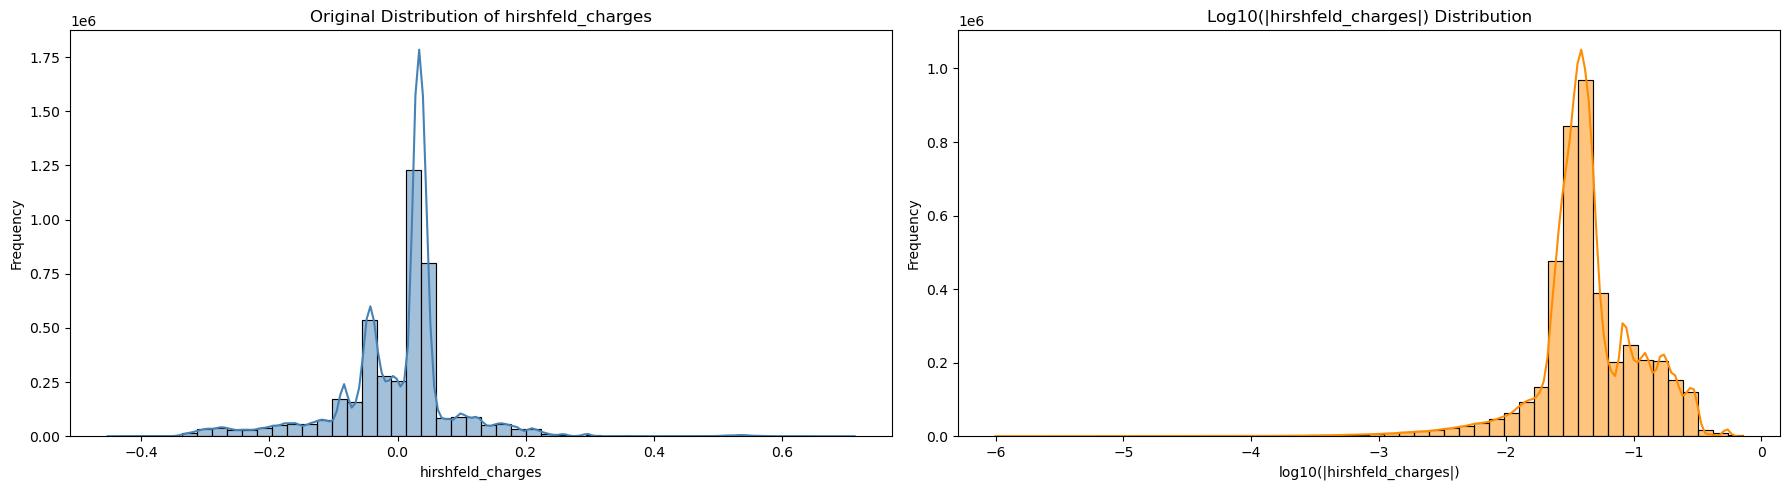

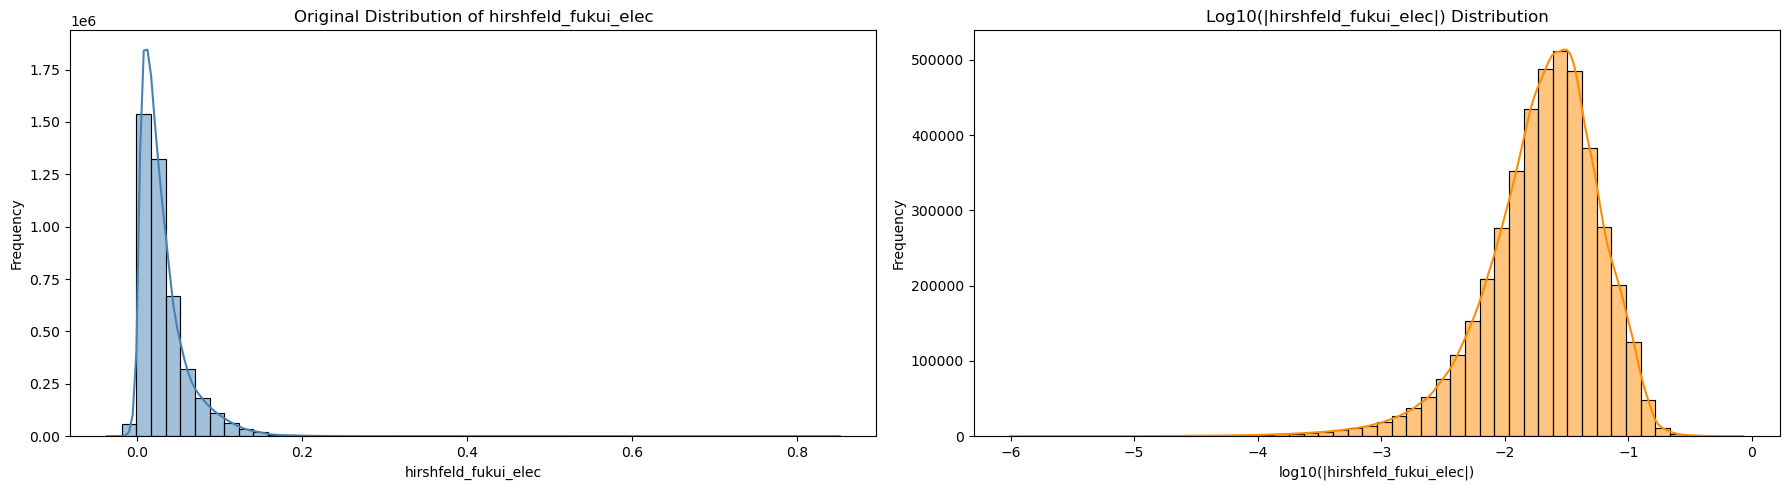

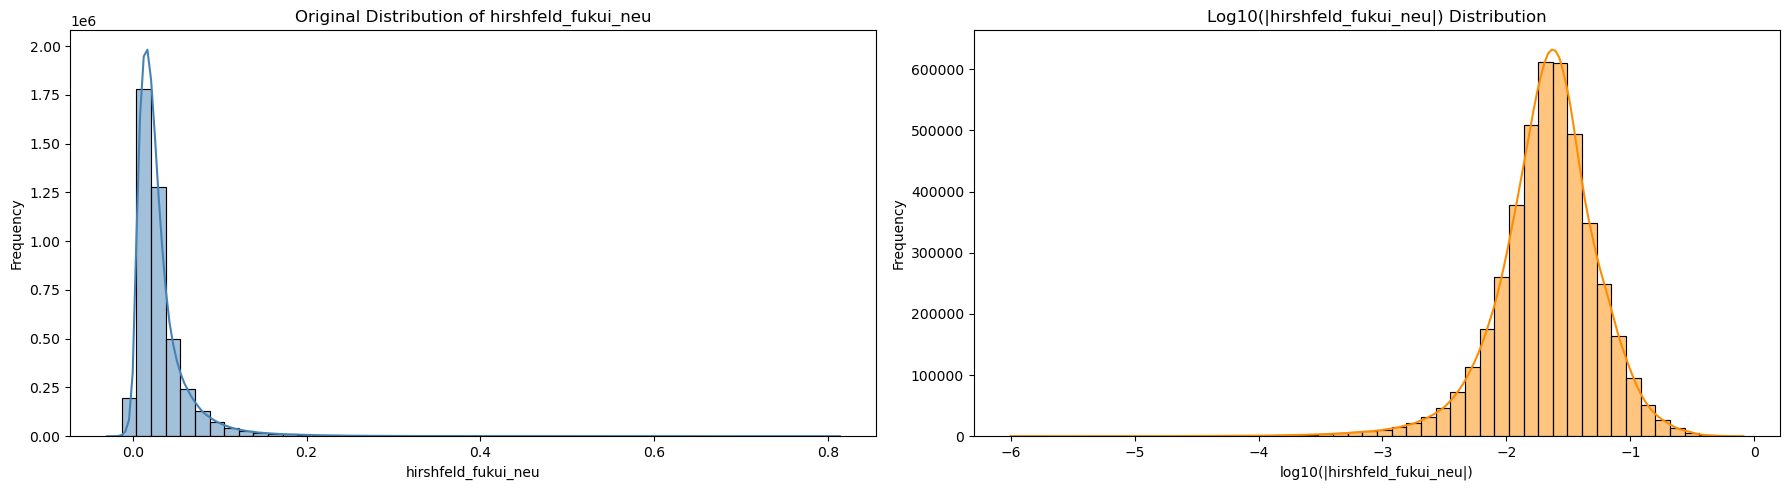

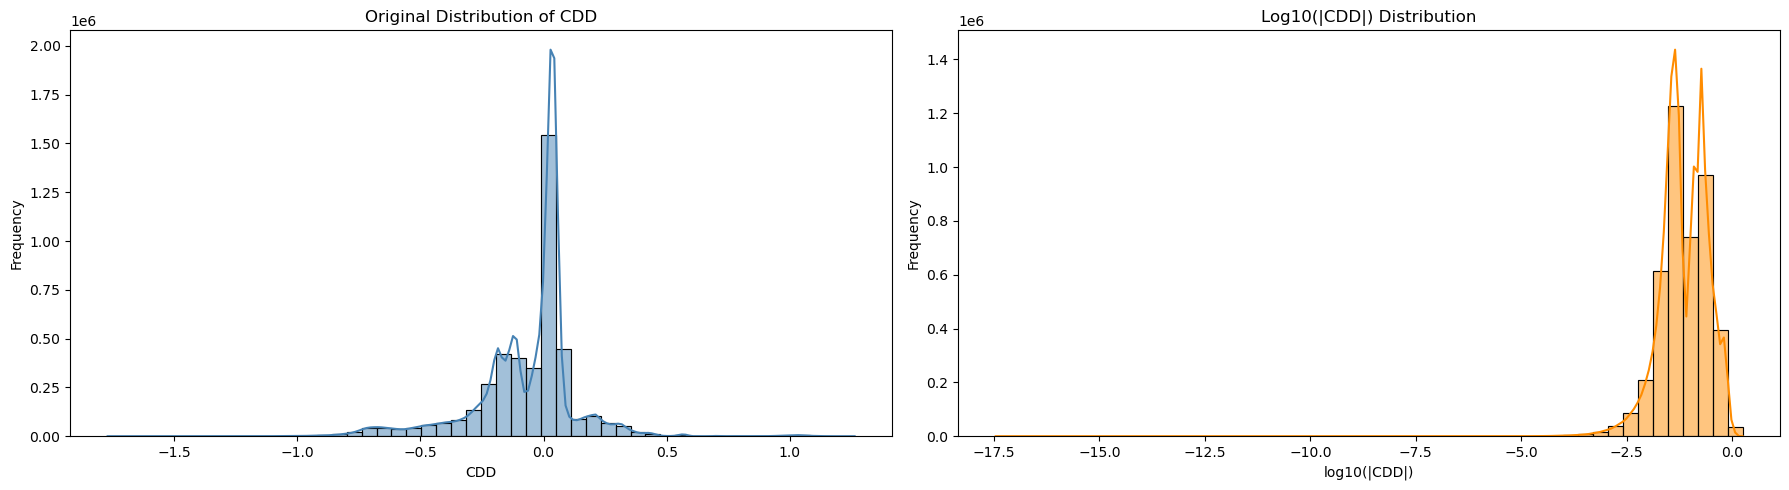

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Updated conversion function to handle comma- and whitespace-separated numbers
def convert_array_str(x):
    if isinstance(x, str):
        s = x.strip()
        if s.startswith('[') and s.endswith(']'):
            s = s[1:-1].strip()
        # Replace commas with spaces to handle comma-separated values
        s = s.replace(',', ' ')
        if s == "":
            return []
        try:
            return [float(item) for item in s.split()]
        except Exception as e:
            print("Error converting:", x)
            return []
    elif isinstance(x, (list, np.ndarray)):
        return list(x)
    else:
        return []

# Load raw dataset from parquet
data = pd.read_parquet('../data/raw/QM_137k.parquet')

# Define columns to process
cols = ['hirshfeld_charges', 'hirshfeld_fukui_elec', 'hirshfeld_fukui_neu', 'CDD']

# Apply conversion for each column
for col in cols:
    data[col] = data[col].apply(convert_array_str)

# Helper function to flatten a column (list of lists -> 1D list)
def flatten_column(df, col):
    return [val for sublist in df[col] if isinstance(sublist, list) for val in sublist]

# Function to compute log10 of absolute value for a list of numbers, filtering out zeros
def compute_log(values):
    arr = np.array(values, dtype=float)
    arr = arr[arr != 0]
    if len(arr) == 0:
        return np.array([])
    return np.log10(np.abs(arr))

# For each column, create a figure with 3 subplots:
# 1) Original distribution, 2) Log10(|value|) distribution, 3) Overlay of both
for col in cols:
    orig_vals = flatten_column(data, col)
    log_vals = compute_log(orig_vals)
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    
    # Left subplot: Original distribution
    sns.histplot(orig_vals, bins=50, kde=True, color='steelblue', ax=axes[0])
    axes[0].set_title(f'Original Distribution of {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')
    
    # Middle subplot: Log-transformed distribution
    sns.histplot(log_vals, bins=50, kde=True, color='darkorange', ax=axes[1])
    axes[1].set_title(f'Log10(|{col}|) Distribution')
    axes[1].set_xlabel(f'log10(|{col}|)')
    axes[1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()


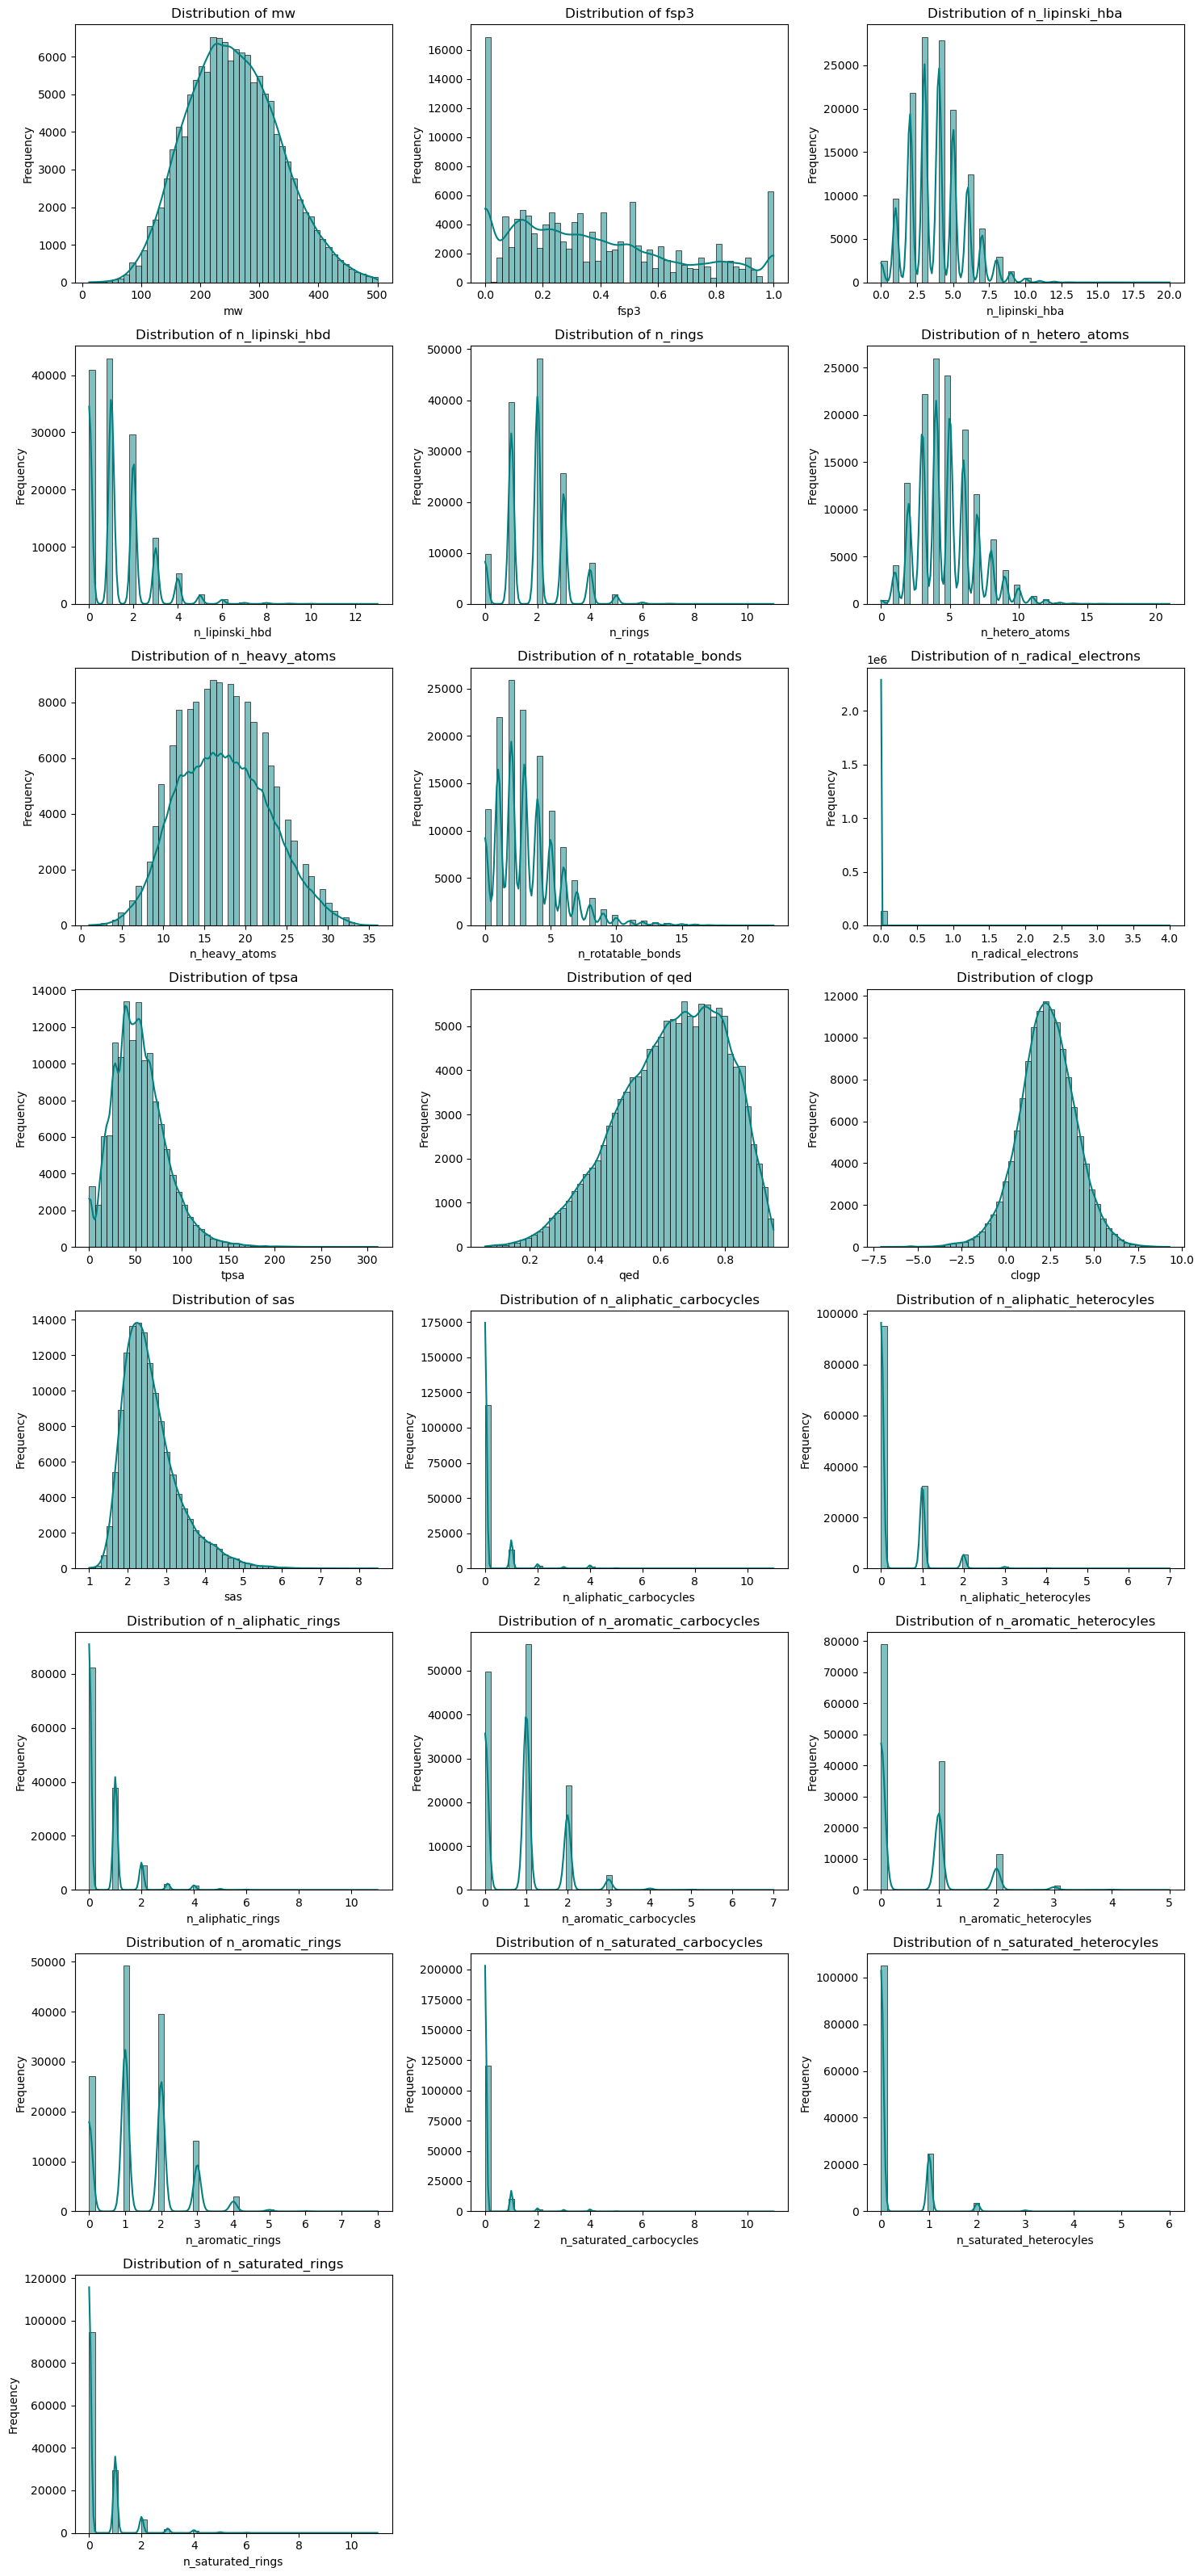

In [17]:
cols = ['mw', 'fsp3', 'n_lipinski_hba', 'n_lipinski_hbd', 'n_rings', 'n_hetero_atoms', 
        'n_heavy_atoms', 'n_rotatable_bonds', 'n_radical_electrons', 'tpsa', 'qed', 'clogp', 
        'sas', 'n_aliphatic_carbocycles', 'n_aliphatic_heterocyles', 'n_aliphatic_rings', 
        'n_aromatic_carbocycles', 'n_aromatic_heterocyles', 'n_aromatic_rings', 
        'n_saturated_carbocycles', 'n_saturated_heterocyles', 'n_saturated_rings']

n_cols = 3
import math
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(desc_data[col].dropna(), bins=50, kde=True, color='teal', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove any unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

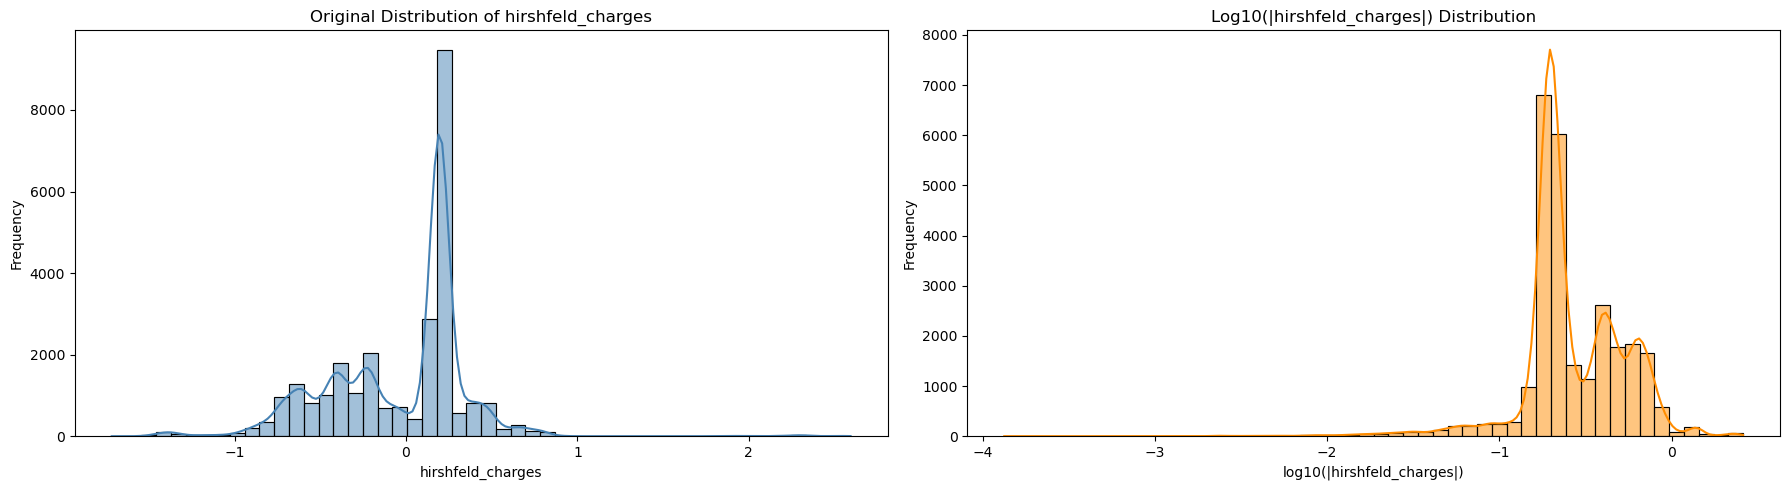

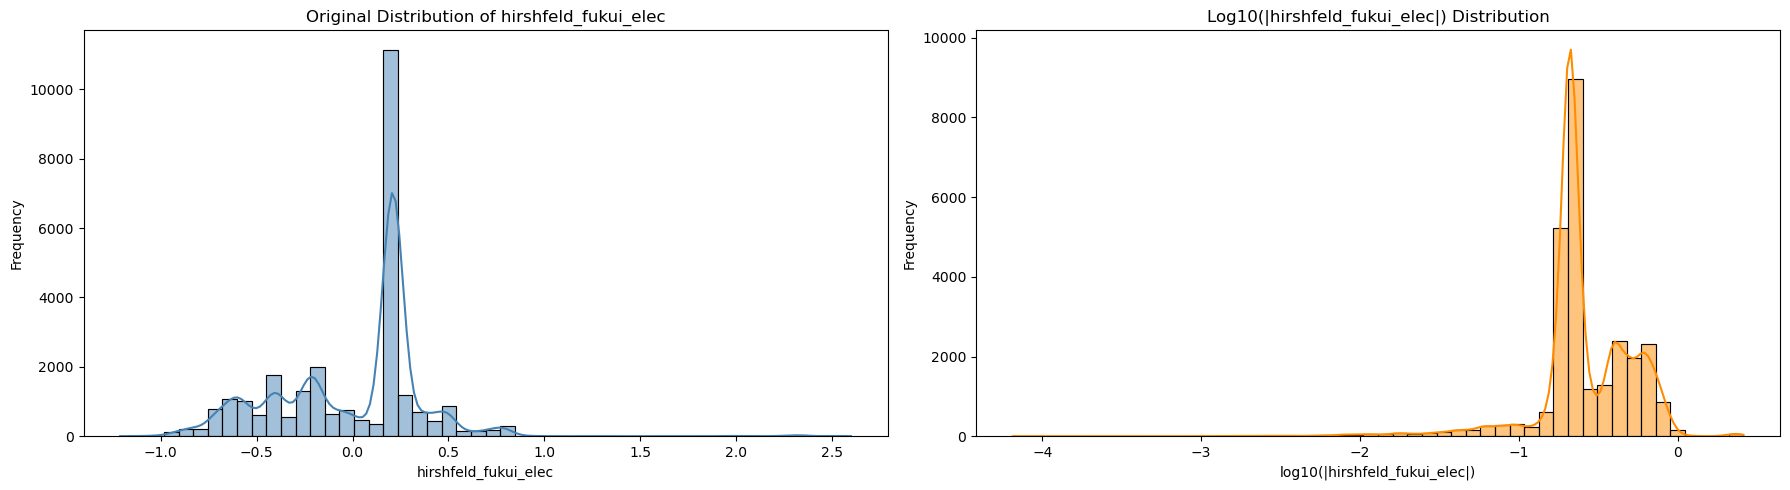

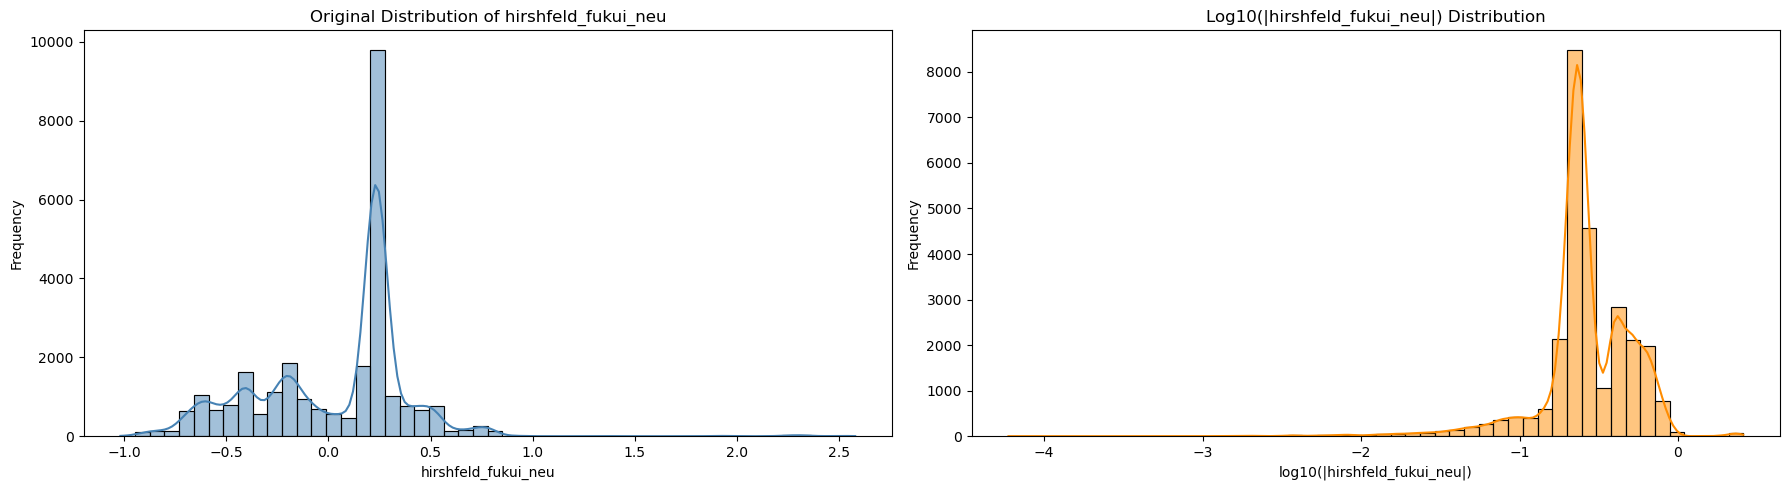

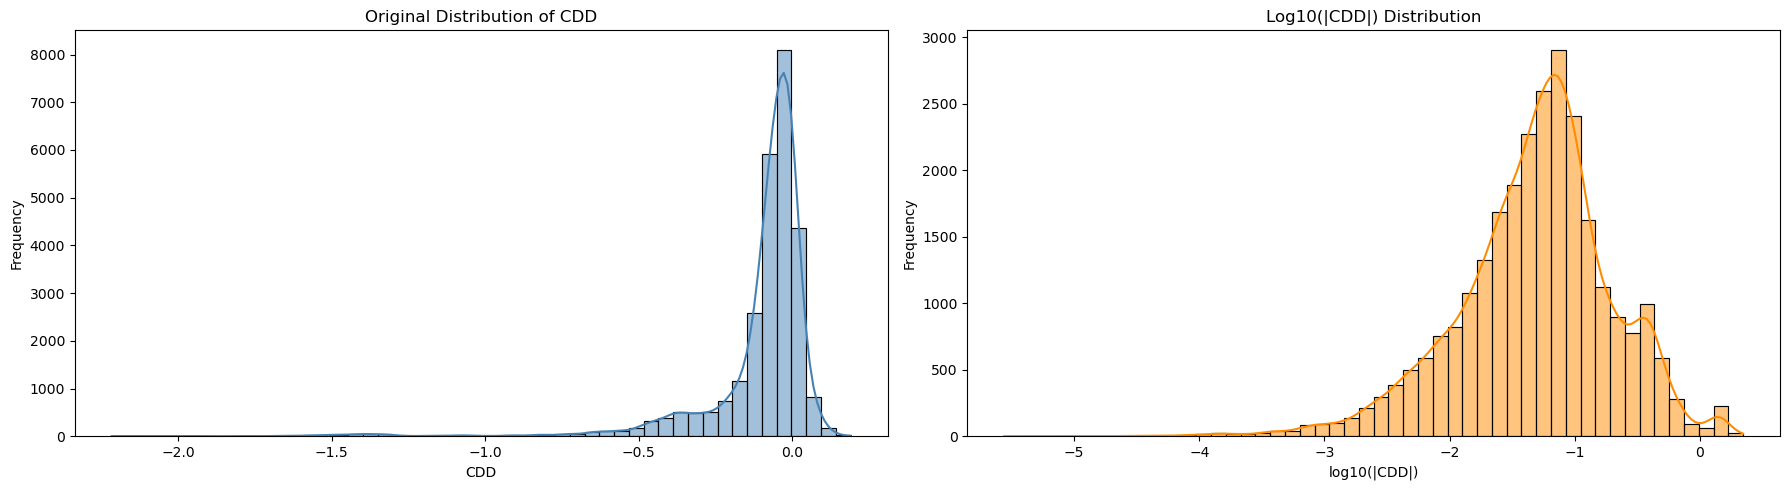

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Updated conversion function to handle comma- and whitespace-separated numbers
def convert_array_str(x):
    if isinstance(x, str):
        s = x.strip()
        if s.startswith('[') and s.endswith(']'):
            s = s[1:-1].strip()
        # Replace commas with spaces to handle comma-separated values
        s = s.replace(',', ' ')
        if s == "":
            return []
        try:
            return [float(item) for item in s.split()]
        except Exception as e:
            print("Error converting:", x)
            return []
    elif isinstance(x, (list, np.ndarray)):
        return list(x)
    else:
        return []

# Load raw dataset from parquet
data = pd.read_csv('../data/processed/qm_calc_data.csv')

# Define columns to process
cols = ['hirshfeld_charges', 'hirshfeld_fukui_elec', 'hirshfeld_fukui_neu', 'CDD']

# Apply conversion for each column
for col in cols:
    data[col] = data[col].apply(convert_array_str)

# Helper function to flatten a column (list of lists -> 1D list)
def flatten_column(df, col):
    return [val for sublist in df[col] if isinstance(sublist, list) for val in sublist]

# Function to compute log10 of absolute value for a list of numbers, filtering out zeros
def compute_log(values):
    arr = np.array(values, dtype=float)
    arr = arr[arr != 0]
    if len(arr) == 0:
        return np.array([])
    return np.log10(np.abs(arr))

# For each column, create a figure with 3 subplots:
# 1) Original distribution, 2) Log10(|value|) distribution, 3) Overlay of both
for col in cols:
    orig_vals = flatten_column(data, col)
    log_vals = compute_log(orig_vals)
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    
    # Left subplot: Original distribution
    sns.histplot(orig_vals, bins=50, kde=True, color='steelblue', ax=axes[0])
    axes[0].set_title(f'Original Distribution of {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')
    
    # Middle subplot: Log-transformed distribution
    sns.histplot(log_vals, bins=50, kde=True, color='darkorange', ax=axes[1])
    axes[1].set_title(f'Log10(|{col}|) Distribution')
    axes[1].set_xlabel(f'log10(|{col}|)')
    axes[1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()


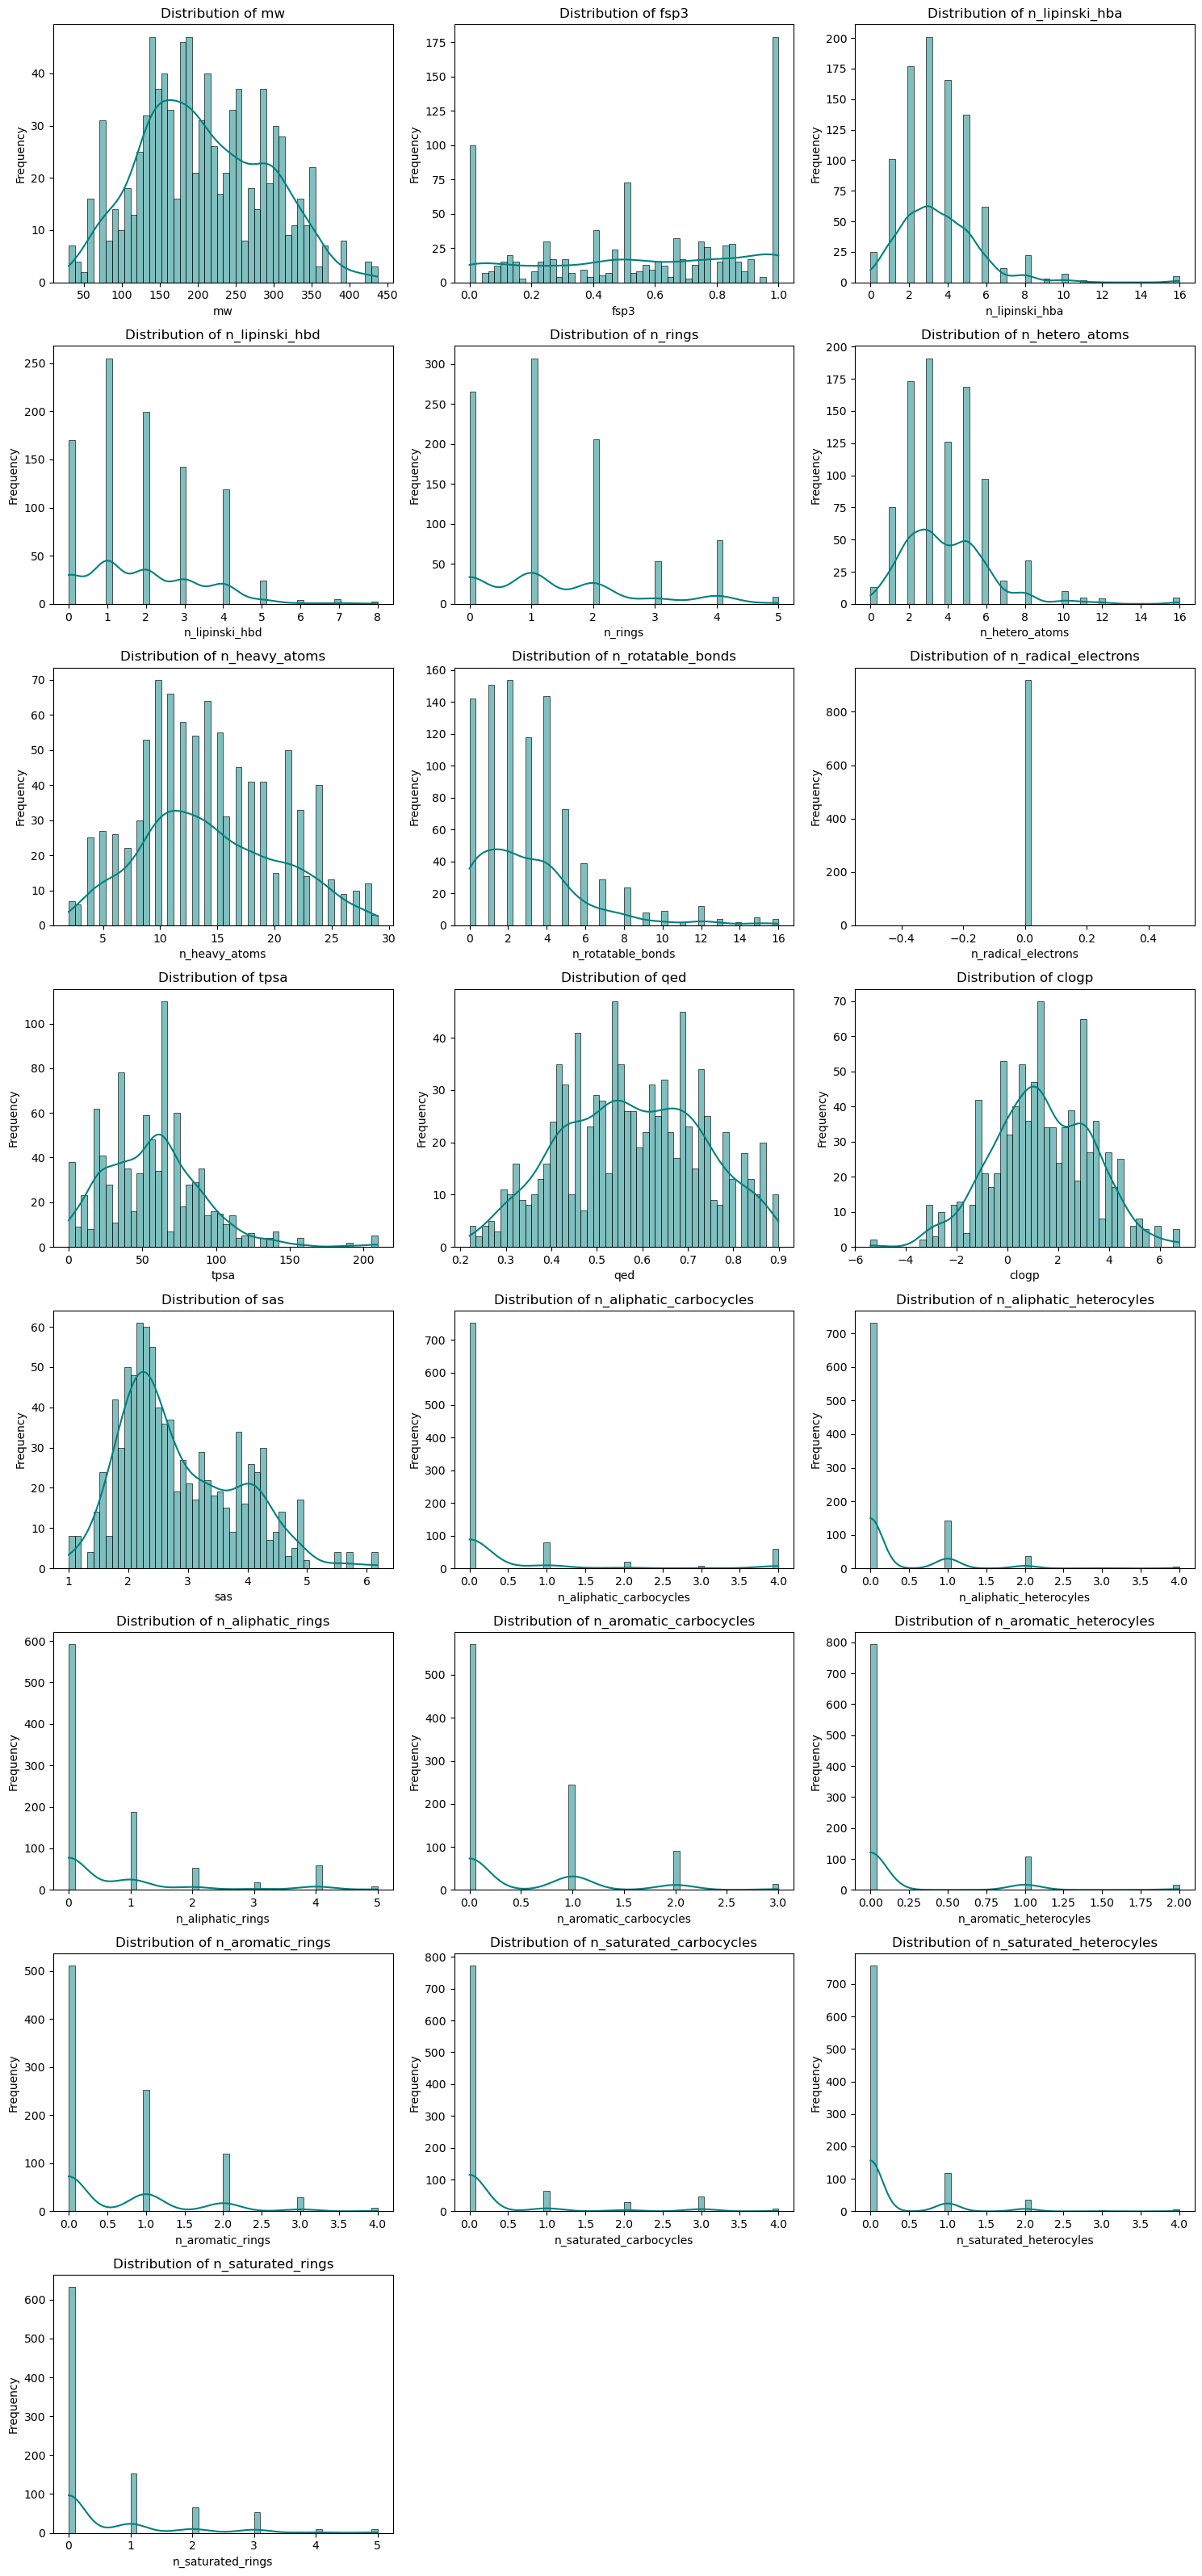

In [18]:
cols = ['mw', 'fsp3', 'n_lipinski_hba', 'n_lipinski_hbd', 'n_rings', 'n_hetero_atoms', 
        'n_heavy_atoms', 'n_rotatable_bonds', 'n_radical_electrons', 'tpsa', 'qed', 'clogp', 
        'sas', 'n_aliphatic_carbocycles', 'n_aliphatic_heterocyles', 'n_aliphatic_rings', 
        'n_aromatic_carbocycles', 'n_aromatic_heterocyles', 'n_aromatic_rings', 
        'n_saturated_carbocycles', 'n_saturated_heterocyles', 'n_saturated_rings']

n_cols = 3
import math
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(proc_merge[col].dropna(), bins=50, kde=True, color='teal', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove any unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

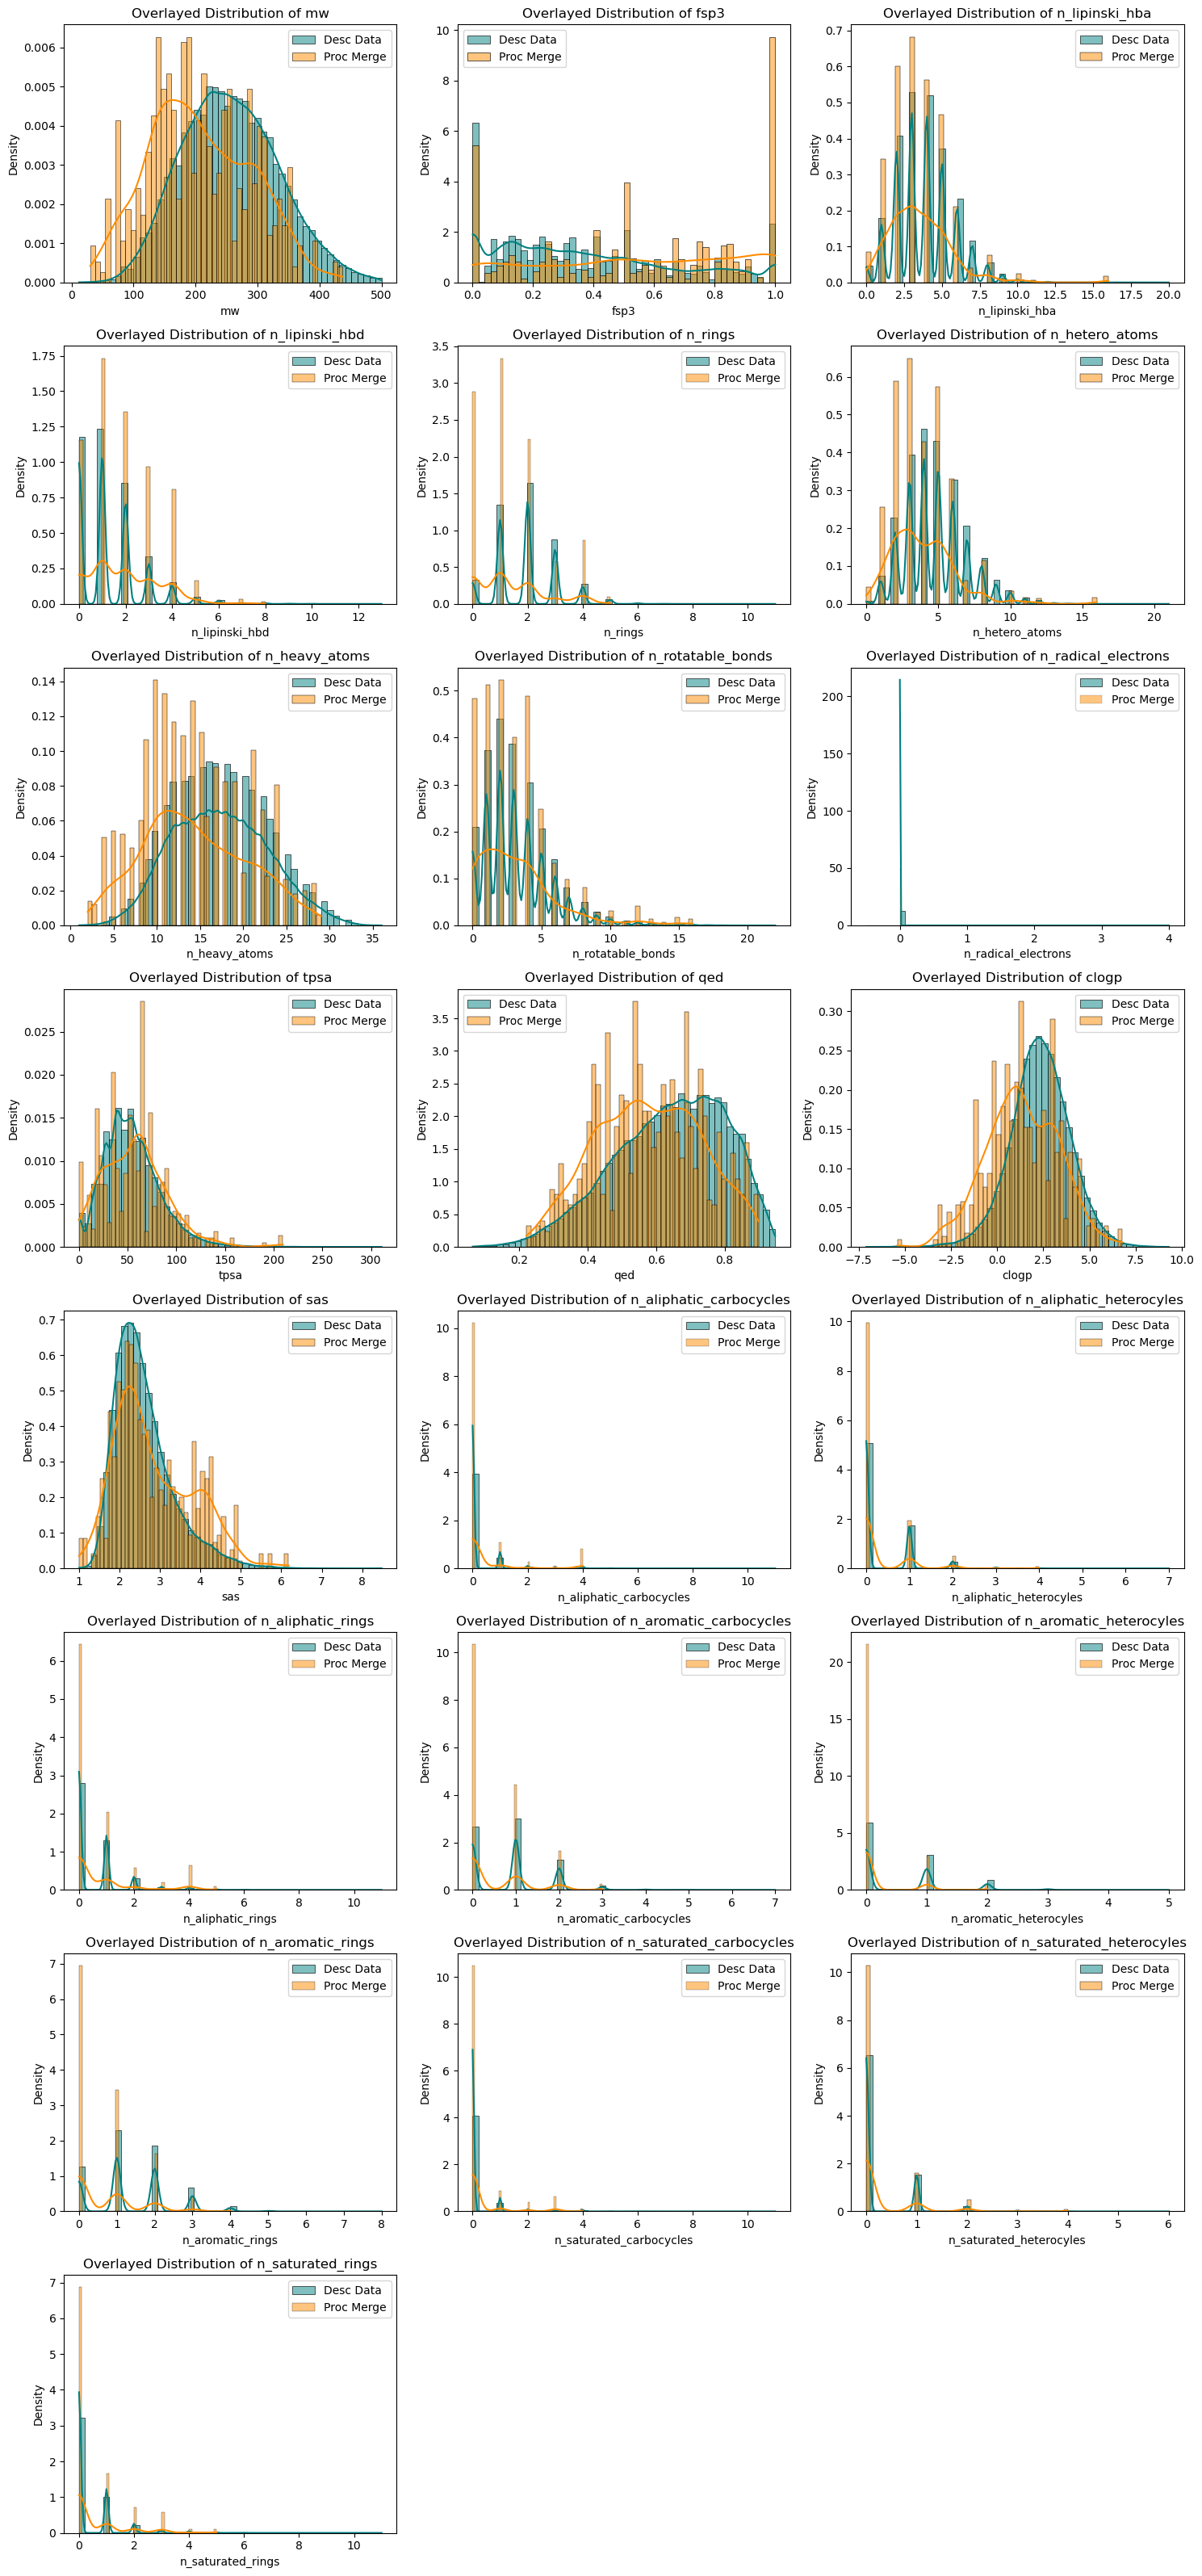

In [19]:
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    'mw', 'fsp3', 'n_lipinski_hba', 'n_lipinski_hbd', 'n_rings', 'n_hetero_atoms',
    'n_heavy_atoms', 'n_rotatable_bonds', 'n_radical_electrons', 'tpsa', 'qed', 'clogp',
    'sas', 'n_aliphatic_carbocycles', 'n_aliphatic_heterocyles', 'n_aliphatic_rings',
    'n_aromatic_carbocycles', 'n_aromatic_heterocyles', 'n_aromatic_rings',
    'n_saturated_carbocycles', 'n_saturated_heterocyles', 'n_saturated_rings'
]

n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(desc_data[col].dropna(), bins=50, stat='density', kde=True,
                 color='teal', label='Desc Data', ax=axes[i], alpha=0.5)
    sns.histplot(proc_merge[col].dropna(), bins=50, stat='density', kde=True,
                 color='darkorange', label='Proc Merge', ax=axes[i], alpha=0.5)
    axes[i].set_title(f'Overlayed Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


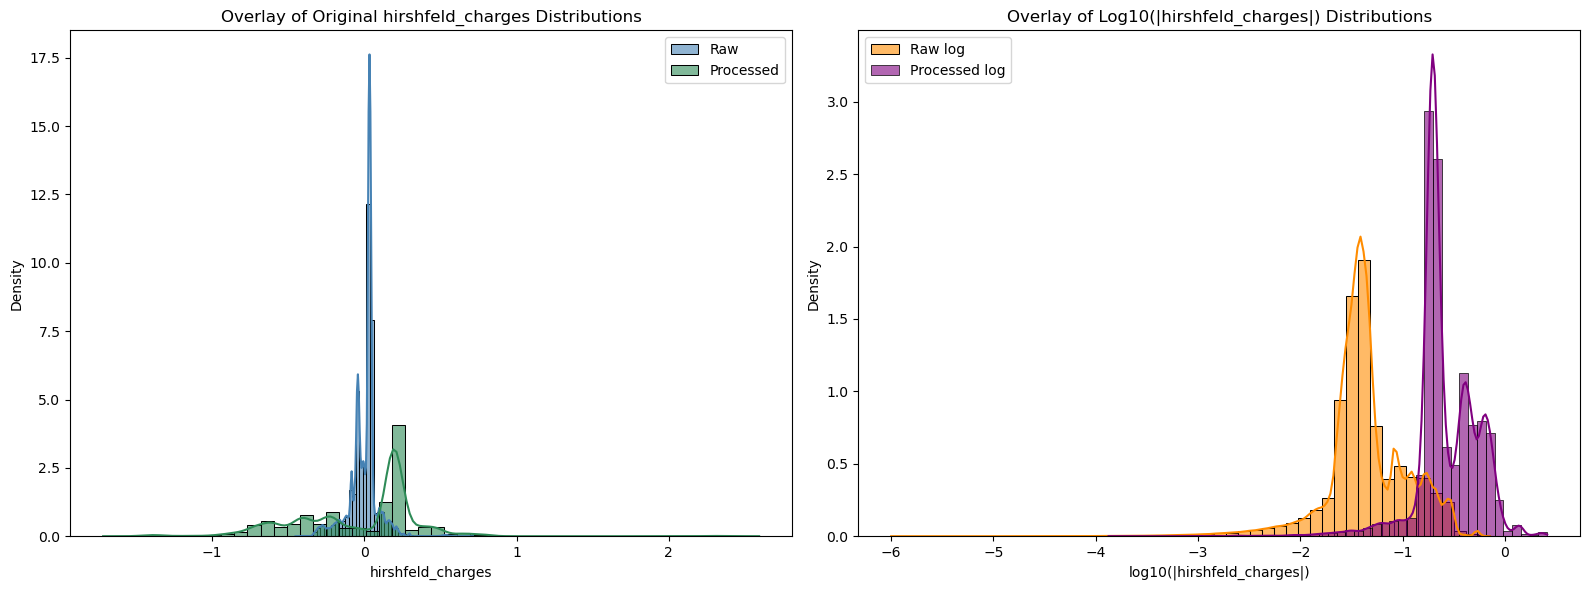

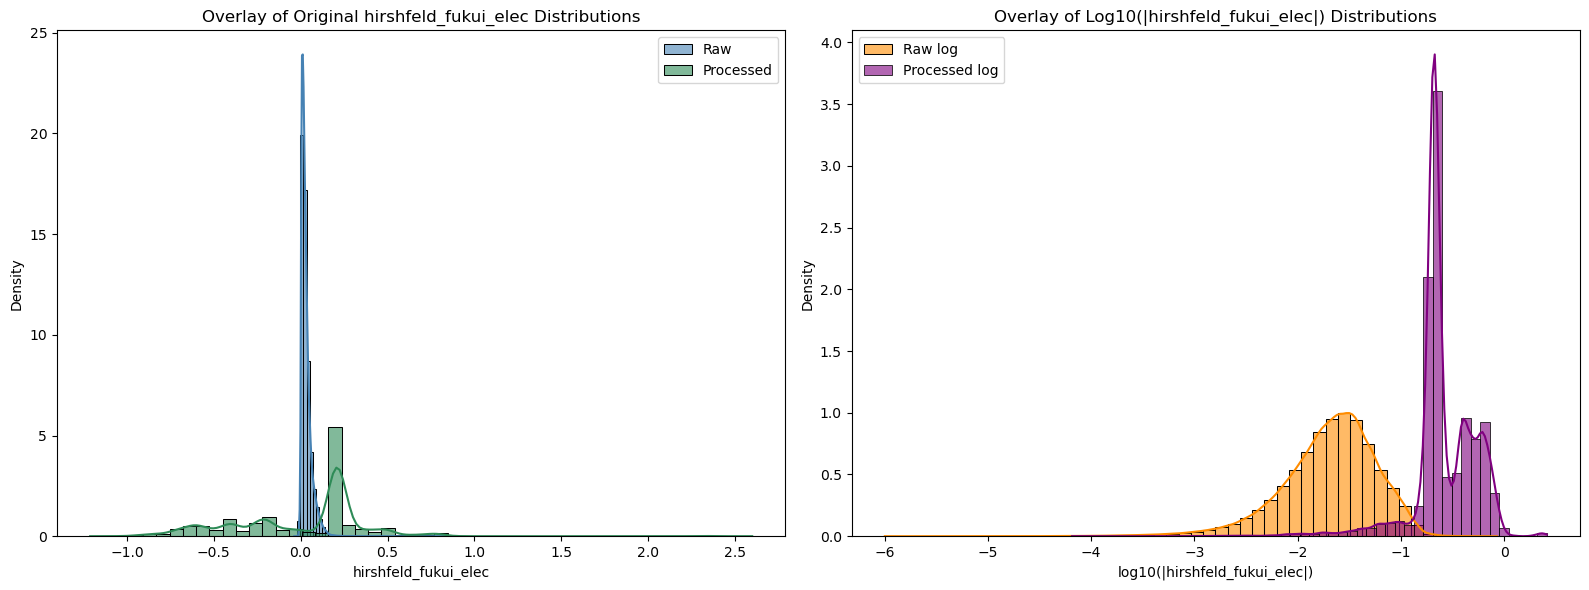

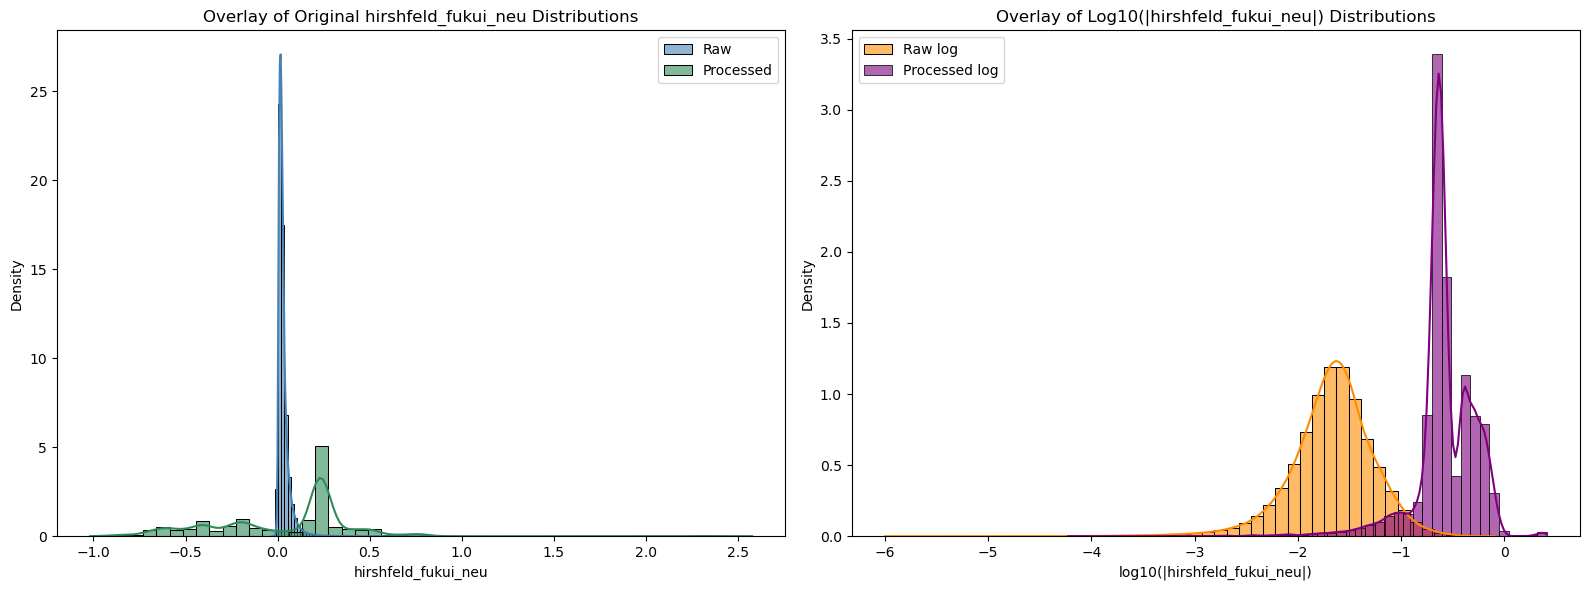

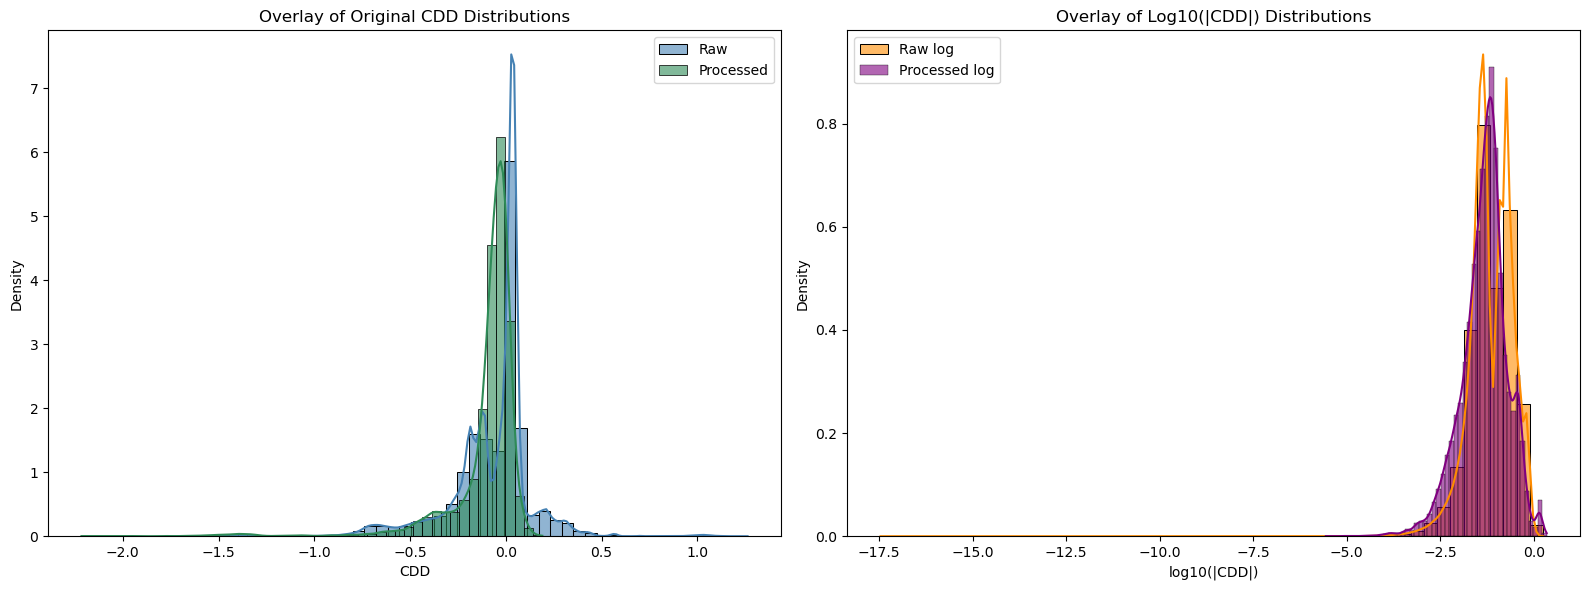

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import ast

# Updated conversion function to handle both comma- and whitespace-separated numbers
def convert_array_str(x):
    if isinstance(x, str):
        s = x.strip()
        if s.startswith('[') and s.endswith(']'):
            s = s[1:-1].strip()
        # Replace commas with spaces to handle comma-separated values
        s = s.replace(',', ' ')
        if s == "":
            return []
        try:
            return [float(item) for item in s.split()]
        except Exception as e:
            print("Error converting:", x)
            return []
    elif isinstance(x, (list, np.ndarray)):
        return list(x)
    else:
        return []

# Load both datasets
raw_data = pd.read_parquet('../data/raw/QM_137k.parquet')
proc_data = pd.read_csv('../data/processed/qm_calc_data.csv')

# Define columns to process
cols = ['hirshfeld_charges', 'hirshfeld_fukui_elec', 'hirshfeld_fukui_neu', 'CDD']

# Apply conversion for each column in both datasets
for col in cols:
    raw_data[col] = raw_data[col].apply(convert_array_str)
    proc_data[col] = proc_data[col].apply(convert_array_str)

# Helper function to flatten a column (list of lists -> 1D list)
def flatten_column(df, col):
    return [val for sublist in df[col] if isinstance(sublist, list) for val in sublist]

# Function to compute log10 of absolute values, filtering out zeros
def compute_log(values):
    arr = np.array(values, dtype=float)
    arr = arr[arr != 0]
    if len(arr) == 0:
        return np.array([])
    return np.log10(np.abs(arr))

# For each column, create a figure with 2 subplots:
# Left: Overlay of original distributions (raw vs processed)
# Right: Overlay of log10(|value|) distributions (raw vs processed)
for col in cols:
    # Flatten the values for raw and processed datasets
    raw_vals = flatten_column(raw_data, col)
    proc_vals = flatten_column(proc_data, col)
    
    # Compute log-transformed values
    raw_log = compute_log(raw_vals)
    proc_log = compute_log(proc_vals)
    
    # Create a figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left subplot: Overlay of original distributions
    sns.histplot(raw_vals, bins=50, kde=True, stat='density', color='steelblue', label='Raw', ax=axes[0], alpha=0.6)
    sns.histplot(proc_vals, bins=50, kde=True, stat='density', color='seagreen', label='Processed', ax=axes[0], alpha=0.6)
    axes[0].set_title(f'Overlay of Original {col} Distributions')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Density')
    axes[0].legend()
    
    # Right subplot: Overlay of log10(|value|) distributions
    sns.histplot(raw_log, bins=50, kde=True, stat='density', color='darkorange', label='Raw log', ax=axes[1], alpha=0.6)
    sns.histplot(proc_log, bins=50, kde=True, stat='density', color='purple', label='Processed log', ax=axes[1], alpha=0.6)
    axes[1].set_title(f'Overlay of Log10(|{col}|) Distributions')
    axes[1].set_xlabel(f'log10(|{col}|)')
    axes[1].set_ylabel('Density')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()


In [5]:
import pandas as pd

# Example summary data gathered from the logs
summary_data = {
    "ChebConv_PReLU": {
        "architecture": {
            "preprocessing_layers": 9,
            "chebconv_layers": 2,
            "chebconv_orders": [10, 16],
            "activation": "PReLU",
            "postprocessing_layers": 2,
            "output_layer": "Linear (128 -> 1)",
            "batchnorm": True
        },
        "hyperparameters": {
            "optimizer": "Lion",
            "learning_rate": 2.2e-5,
            "weight_decay": 3e-5,
            "batch_size": 1024,
            "scheduler": "Reduce every 80 epochs by factor 0.2",
            "early_stopping_patience": 5
        },
        "results": {
            "RMSE": 0.023
        }
    },
    "ChebConv_KAN_ReLU": {
        "architecture": {
            "preprocessing_layers": 9,
            "chebconv_layers": 2,
            "chebconv_orders": [10, 16],
            "activation": "ReLU",
            "postprocessing_layers": 2,
            "output_layer": "Linear (128 -> 1)",
            "batchnorm": True,
            "kan_layers": True
        },
        "hyperparameters": {
            "optimizer": "Lion",
            "learning_rate": 2.2e-5,
            "weight_decay": 3e-5,
            "batch_size": 1024,
            "scheduler": "Reduce every 80 epochs by factor 0.2",
            "early_stopping_patience": 5
        },
        "results": {
            "RMSE": 0.022
        }
    },
    "GraphSAGE": {
        "architecture": {
            "preprocessing_layers": 9,
            "graphsage_layers": 2,
            "hidden_dimensions": [128, 1024, 1024],
            "aggregation": "mean",
            "postprocessing_layers": 2,
            "output_layer": "Linear (128 -> 1)",
            "activation": "PReLU",
            "batchnorm": True
        },
        "hyperparameters": {
            "optimizer": "Lion",
            "learning_rate": 2.2e-5,
            "weight_decay": 3e-5,
            "batch_size": 1024,
            "scheduler": "Reduce every 80 epochs by factor 0.2",
            "early_stopping_patience": 5
        },
        "results": {
            "RMSE": 0.035
        }
    },
    "TransformerConv": {
        "architecture": {
            "preprocessing_layers": {
                "node_features": 9,
                "edge_features": 9
            },
            "transformerconv_layers": 2,
            "attention_heads": [16, 20],
            "concat_attention": True,
            "postprocessing_layers": 2,
            "output_layer": "Linear (128 -> 1)",
            "activation": "PReLU",
            "batchnorm": True
        },
        "hyperparameters": {
            "optimizer": "Lion",
            "learning_rate": 2.2e-5,
            "weight_decay": 3e-5,
            "batch_size": 1024,
            "scheduler": "Reduce every 80 epochs by factor 0.2",
            "early_stopping_patience": 5
        },
        "results": {
            "RMSE": 0.20
        }
    },
    "GINEConv": {
        "architecture": {
            "preprocessing_layers": {
                "node": "Linear (333 -> 64)",
                "edge": "Linear (414 -> 64)"
            },
            "gineconv_layers": 2,
            "mlp": {
                "layers": ["Linear (64 -> 64)", "ReLU", "Linear (64 -> 64)"]
            },
            "postprocessing_layers": {
                "layer1": "Linear (64 -> 128)",
                "layer2": "Linear (128 -> 64)",
                "output_layer": "Linear (64 -> 1)"
            },
            "activation": "ReLU",
            "batchnorm": True,
            "parameter_count": "≈73k"
        },
        "hyperparameters": {
            "optimizer": "Lion",
            "learning_rate": 2.2e-5,
            "weight_decay": 3e-5,
            "batch_size": 1024,
            "scheduler": "Reduce every 80 epochs by factor 0.2",
            "early_stopping_patience": 5
        },
        "results": {
            "RMSE": 0.23
        }
    }
}


df_summary = pd.DataFrame(summary_data)
# Reorder columns if desired
df_summary = df_summary[["File", "Params (M)", "Best Val Loss", "Training Time", "Notes"]]

display(df_summary)


,ChebConv_PReLU,ChebConv_KAN_ReLU,GraphSAGE,TransformerConv,GINEConv
architecture,"{'preprocessing_layers': 9, 'chebconv_layers':...","{'preprocessing_layers': 9, 'chebconv_layers':...","{'preprocessing_layers': 9, 'graphsage_layers'...","{'preprocessing_layers': {'node_features': 9, ...",{'preprocessing_layers': {'node': 'Linear (333...
hyperparameters,"{'optimizer': 'Lion', 'learning_rate': 2.2e-05...","{'optimizer': 'Lion', 'learning_rate': 2.2e-05...","{'optimizer': 'Lion', 'learning_rate': 2.2e-05...","{'optimizer': 'Lion', 'learning_rate': 2.2e-05...","{'optimizer': 'Lion', 'learning_rate': 2.2e-05..."
results,{'RMSE': 0.023},{'RMSE': 0.022},{'RMSE': 0.035},{'RMSE': 0.2},{'RMSE': 0.23}
